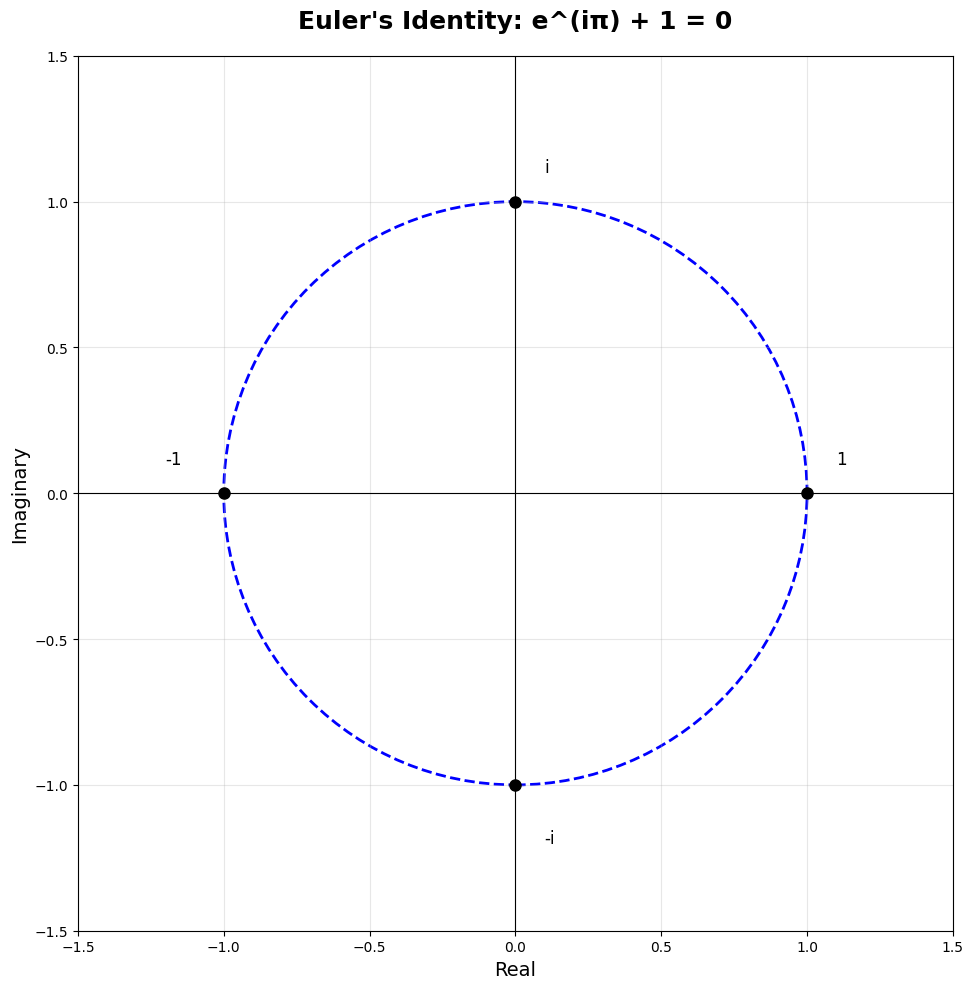

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.8)
ax.axvline(x=0, color='k', linewidth=0.8)
ax.set_xlabel('Real', fontsize=14)
ax.set_ylabel('Imaginary', fontsize=14)

# Draw unit circle
unit_circle = Circle((0, 0), 1, fill=False, edgecolor='blue', linewidth=2, linestyle='--')
ax.add_patch(unit_circle)

# Initialize plot elements
point, = ax.plot([], [], 'ro', markersize=12)
radius_line, = ax.plot([], [], 'g-', linewidth=2)
trace, = ax.plot([], [], 'r-', linewidth=1, alpha=0.5)
text = ax.text(0.05, 1.3, '', fontsize=16, weight='bold')
equation_text = ax.text(-1.4, -1.3, '', fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

# Title
ax.set_title("Euler's Identity: e^(iπ) + 1 = 0", fontsize=18, weight='bold', pad=20)

# Arrays to store the trace
trace_x = []
trace_y = []

# Animation function
def animate(frame):
    # Calculate angle (0 to π)
    angle = frame * np.pi / 100  # 100 frames to reach π
    
    # Calculate position on unit circle
    x = np.cos(angle)
    y = np.sin(angle)
    
    # Update point position
    point.set_data([x], [y])
    
    # Update radius line
    radius_line.set_data([0, x], [0, y])
    
    # Update trace
    trace_x.append(x)
    trace_y.append(y)
    trace.set_data(trace_x, trace_y)
    
    # Update angle text
    text.set_text(f'Angle: {angle:.3f} radians ({angle*180/np.pi:.1f}°)')
    
    # Update equation text
    if angle < 0.1:
        equation_text.set_text(f'e^(i·0) = 1')
    elif abs(angle - np.pi) < 0.01:
        equation_text.set_text(f'e^(i·π) = -1\nTherefore: e^(i·π) + 1 = 0')
        equation_text.set_color('red')
        equation_text.set_fontsize(16)
    else:
        equation_text.set_text(f'e^(i·{angle:.3f}) = {x:.3f} + {y:.3f}i')
        equation_text.set_color('black')
        equation_text.set_fontsize(14)
    
    # Highlight when we reach π
    if abs(angle - np.pi) < 0.01:
        point.set_markersize(20)
        point.set_color('red')
        radius_line.set_color('red')
        radius_line.set_linewidth(3)
    
    return point, radius_line, trace, text, equation_text

# Initialize animation
def init():
    point.set_data([], [])
    radius_line.set_data([], [])
    trace.set_data([], [])
    text.set_text('')
    equation_text.set_text('')
    trace_x.clear()
    trace_y.clear()
    return point, radius_line, trace, text, equation_text

# Create animation
anim = animation.FuncAnimation(fig, animate, init_func=init,
                              frames=101, interval=50, blit=True, repeat=True)

# Add markers for key points
ax.plot(1, 0, 'ko', markersize=8)
ax.plot(-1, 0, 'ko', markersize=8)
ax.plot(0, 1, 'ko', markersize=8)
ax.plot(0, -1, 'ko', markersize=8)

# Add labels for key points
ax.annotate('1', xy=(1, 0), xytext=(1.1, 0.1), fontsize=12)
ax.annotate('-1', xy=(-1, 0), xytext=(-1.2, 0.1), fontsize=12)
ax.annotate('i', xy=(0, 1), xytext=(0.1, 1.1), fontsize=12)
ax.annotate('-i', xy=(0, -1), xytext=(0.1, -1.2), fontsize=12)

plt.tight_layout()
plt.show()

# Optional: Save as gif
# anim.save('euler_identity.gif', writer='pillow', fps=20)